# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danielajetunmobi/flyrank/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup — cohort builder

Two decision points, not one. The `auditing-signals` skill requires re-running a test on a
different slice (*"a real signal survives; noise doesn't"*), and every number in ML-02 → ML-05
rests on `2026-03-31` alone. `D1` is that familiar date; `D2 = 2026-05-31` gives a
**non-overlapping** future window for the survival check.

Carries forward every correction established in ML-05: position is zero-based (`+1`, per
[Google's reference](https://support.google.com/webmasters/answer/12917991)), the future window is
30 dates with an exclusive upper bound, deleted and unpublished pages are excluded, clients whose
tracking starts inside the prior window are dropped, `has_*` flags are computed before any fill,
and `ORDER BY` keeps the row order deterministic.

In [1]:
%pip install -q duckdb huggingface_hub pandas numpy matplotlib python-dotenv

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

token = os.environ.get("HF_TOKEN")
if not token:
    import getpass
    token = getpass.getpass("Hugging Face token (read): ")

REPO = "FlyRank/internship-warehouse"
MONTHS = ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]

daily_files = [
    hf_hub_download(repo_id=REPO, repo_type="dataset",
                    filename=f"fact_content_daily_performance/month={m}/data_0.parquet", token=token)
    for m in MONTHS
]
dim_content_file = hf_hub_download(repo_id=REPO, repo_type="dataset",
                                   filename="dim_content.parquet", token=token)
clients_file = hf_hub_download(repo_id=REPO, repo_type="dataset",
                               filename="dim_clients.parquet", token=token)

con = duckdb.connect()
REL = "read_parquet([" + ", ".join(f"'{f}'" for f in daily_files) + "])"

D1 = "2026-03-31"
D2 = "2026-05-31"


def build_cohort(decision_date):
    """One row per content item at `decision_date`. All ML-05 corrections applied."""
    q = f"""
    WITH prior AS (
        SELECT content_hash_id, ANY_VALUE(client_hash_id) AS client_hash_id,
            SUM(gsc_impressions) AS gsc_impressions,
            SUM(gsc_clicks)      AS gsc_clicks,
            SUM(gsc_sum_position) AS gsc_sum_position,
            COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_impressions,
            COUNT(*) FILTER (WHERE ga4_sessions > 0)    AS days_with_sessions,
            BOOL_OR(ga4_data_available) AS ga4_data_available,
            SUM(ga4_sessions)         AS ga4_sessions,
            SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
            SUM(ga4_pageviews)        AS ga4_pageviews,
            SUM(scroll_events)        AS scroll_events,
            SUM(gsc_impressions) FILTER (
                WHERE report_date >= DATE '{decision_date}' - INTERVAL 60 DAY
                  AND report_date <  DATE '{decision_date}' - INTERVAL 30 DAY) AS trend_baseline_impr,
            SUM(gsc_impressions) FILTER (
                WHERE report_date >= DATE '{decision_date}' - INTERVAL 30 DAY) AS trend_recent_impr
        FROM {REL}
        WHERE report_date >= DATE '{decision_date}' - INTERVAL 90 DAY
          AND report_date <  DATE '{decision_date}'
        GROUP BY content_hash_id
    ),
    future AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS future_impressions
        FROM {REL}
        WHERE report_date >= DATE '{decision_date}'
          AND report_date <  DATE '{decision_date}' + INTERVAL 30 DAY
        GROUP BY content_hash_id
    )
    SELECT p.*, f.future_impressions
    FROM prior p JOIN future f USING (content_hash_id)
    WHERE p.trend_baseline_impr > 0 AND p.trend_recent_impr > 0
    ORDER BY content_hash_id
    """
    df = con.sql(q).df()

    dim = con.sql(f"SELECT * FROM read_parquet('{dim_content_file}')").df().drop(columns=["client_hash_id"])
    df = df.merge(dim, on="content_hash_id", how="left")
    clients = con.sql(f"SELECT client_hash_id, gsc_data_start FROM read_parquet('{clients_file}')").df()
    df = df.merge(clients, on="client_hash_id", how="left")

    live = df["is_deleted"].fillna(False).eq(False) & df["is_published"].fillna(True).eq(True)
    df = df[live]
    window_start = pd.Timestamp(decision_date) - pd.Timedelta(days=90)
    df = df[df["gsc_data_start"].isna() | (df["gsc_data_start"] <= window_start)].copy()

    df["gsc_avg_position"] = df["gsc_sum_position"] / df["gsc_impressions"] + 1
    df["ctr"] = (df["gsc_clicks"] / df["gsc_impressions"].replace(0, np.nan) * 100).fillna(0)
    df["engagement_rate"] = (df["ga4_engaged_sessions"] / df["ga4_sessions"].replace(0, np.nan) * 100).fillna(0)

    ts = pd.Timestamp(decision_date)
    df["content_age_days"] = (ts - pd.to_datetime(df["content_created_date"])).dt.days
    df["days_since_last_update"] = (ts - pd.to_datetime(df["content_updated_date"])).dt.days

    df["has_ga4_data"]      = df["ga4_data_available"].fillna(False).astype(int)
    df["has_keyword_data"]  = df["search_volume"].notna().astype(int)
    df["has_word_count"]    = df["word_count"].notna().astype(int)
    df["has_backlink_data"] = df["backlinks"].notna().astype(int)

    df["prior_trend_pct"] = (df["trend_recent_impr"] - df["trend_baseline_impr"]) / df["trend_baseline_impr"] * 100
    df["was_declining"]   = df["prior_trend_pct"] <= -20
    recent_daily = df["trend_recent_impr"] / 30
    future_daily = df["future_impressions"] / 30
    df["future_change_pct"] = (future_daily - recent_daily) / recent_daily * 100
    df["future_decline"]  = (~df["was_declining"]) & (df["future_change_pct"] <= -20)
    df["future_recovery"] = ( df["was_declining"]) & (df["future_change_pct"] >=  20)

    df["decision_date"] = decision_date
    return df


d1 = build_cohort(D1)
d2 = build_cohort(D2)

for name, d in [("D1 " + D1, d1), ("D2 " + D2, d2)]:
    print(f"{name}:  {len(d):>7,} pages | {d['client_hash_id'].nunique():>3} clients | "
          f"future_decline base rate {d['future_decline'].mean():.1%}")


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


D1 2026-03-31:  115,603 pages |  29 clients | future_decline base rate 40.3%
D2 2026-05-31:  175,716 pages |  40 clients | future_decline base rate 36.6%


**Verdict helper.** The skill sets a hard rule: *no verdict from a bucket with fewer than ~50 rows*
(~30 for cross-cuts), and every rate shown next to its `n`. `bucket_table` enforces both — buckets
below the floor are labelled `insufficient data` rather than reported as a rate. It also weights
rates by their denominator where one is given, because averaging per-row rates is not the true rate.

In [2]:
N_FLOOR = 50


def bucket_table(df, bucket, outcome, weight=None, n_floor=N_FLOOR):
    """Grouped rate table with visible n and a sample-size floor.

    outcome : boolean column -> share True, or numeric column -> median.
    weight  : optional denominator column; when given the rate is
              sum(outcome) / sum(weight), not the mean of per-row rates.
    """
    rows = []
    for key, g in df.groupby(bucket, observed=True):
        n = len(g)
        if weight is not None:
            rate = g[outcome].sum() / g[weight].sum() * 100 if g[weight].sum() else np.nan
        elif df[outcome].dtype == bool:
            rate = g[outcome].mean() * 100
        else:
            rate = g[outcome].median()
        rows.append({
            bucket if isinstance(bucket, str) else "bucket": key,
            "n": n,
            "value": round(rate, 2) if n >= n_floor else None,
            "note": "" if n >= n_floor else f"insufficient data (n<{n_floor})",
        })
    return pd.DataFrame(rows)


def verdict(label, text):
    """Print a verdict in the skill's four-word vocabulary."""
    assert label in {"CONFIRMED", "OPPOSITE", "MIXED", "FALSE", "INSUFFICIENT DATA"}, label
    print(f"VERDICT: {label} -- {text}")

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

*Look before deciding: distributions of your key fields. Note the heavy tails.*

**What this section owes the rest of the notebook.** Every later test depends on knowing which
fields are heavy-tailed, because plain correlation on raw heavy-tailed values is dominated by the
giants and can flip sign after a log transform. Fields worth describing: `gsc_impressions`,
`gsc_clicks`, `gsc_avg_position`, `ctr`, `prior_trend_pct`, `future_change_pct`, `word_count`,
`backlinks`, `search_volume`.

Watch for: values that look like sentinels rather than measurements, ratios that exceed 100%
(numerator and denominator from different systems), and columns whose zeros mean "not measured"
rather than zero. `d1` and `d2` are ready to use.

In [3]:
# Every numeric field in the cohort, described. Flags are excluded -- they are
# 0/1 by construction and carry no distribution.
skip = {"has_ga4_data", "has_keyword_data", "has_word_count", "has_backlink_data"}
num_cols = [c for c in d1.columns
            if pd.api.types.is_numeric_dtype(d1[c]) and not pd.api.types.is_bool_dtype(d1[c])
            and c not in skip]


def describe(df):
    rows = []
    for c in num_cols:
        s = df[c]
        nz = s.dropna()
        p50 = nz.median() if len(nz) else np.nan
        p99 = nz.quantile(0.99) if len(nz) else np.nan
        rows.append({
            "column": c,
            "miss%": round(s.isna().mean() * 100, 1),
            "zero%": round((nz == 0).mean() * 100, 1) if len(nz) else np.nan,
            "min": round(nz.min(), 2) if len(nz) else np.nan,
            "p50": round(p50, 2),
            "p90": round(nz.quantile(0.90), 2) if len(nz) else np.nan,
            "p99": round(p99, 2),
            "max": round(nz.max(), 2) if len(nz) else np.nan,
            "p99/p50": round(p99 / p50, 1) if p50 and p50 > 0 else np.nan,
        })
    return pd.DataFrame(rows)


desc = describe(d1)
pd.set_option("display.width", 200)
print("D1 2026-03-31 -- distribution of every numeric field")
print(desc.to_string(index=False))

# p99/p50 > 10 is a practical heavy-tail marker: the top percentile is an order
# of magnitude above the typical row, so plain correlation will follow the giants.
heavy = desc[desc["p99/p50"] > 10]["column"].tolist()
print()
print(f"Heavy-tailed (p99/p50 > 10): {len(heavy)} of {len(num_cols)}")
for c in heavy:
    print(f"  {c}")

# Ratio columns can legitimately exceed 100% when numerator and denominator come
# from different measurement systems -- check rather than assume a data bug.
print()
for c in ["ctr", "engagement_rate"]:
    over = (d1[c] > 100).sum()
    print(f"{c}: {over:,} rows above 100%  (max {d1[c].max():.1f})")

# Provenance: is dim_content a point-in-time record, or a snapshot taken at export?
# days_since_last_update going negative is the symptom; this is the direct check.
for tag, d, D in [("D1", d1, D1), ("D2", d2, D2)]:
    upd = pd.to_datetime(d["content_updated_date"])
    print(f"{tag} {D}: content_updated_date AFTER the decision point for "
          f"{(upd > pd.Timestamp(D)).mean():.1%} of cohort pages; latest value {upd.max().date()}")

# The fact table's own cutoff, for comparison with the dimension's dates.
print()
print("fact table max report_date:",
      con.sql(f"SELECT MAX(report_date) AS d FROM {REL}").df().iloc[0, 0].date())

# Is content_updated_date editorial activity, or batch processing?
print()
print("most common content_updated_date values across dim_content:")
print(con.sql(f"""
SELECT content_updated_date, COUNT(*) AS n,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_all_content
FROM read_parquet('{dim_content_file}')
GROUP BY 1 ORDER BY n DESC LIMIT 3
""").df().to_string(index=False))

D1 2026-03-31 -- distribution of every numeric field
                column  miss%  zero%     min      p50      p90       p99         max  p99/p50
       gsc_impressions    0.0    0.0    2.00   678.00 11998.00  58672.82   797764.00     86.5
            gsc_clicks    0.0   43.9    0.00     1.00    31.00    218.00     9150.00    218.0
      gsc_sum_position    0.0    0.0    0.00  7656.00 92781.20 591085.04 10862254.00     77.2
 days_with_impressions    0.0    0.0    2.00    77.00    90.00     90.00       90.00      1.2
    days_with_sessions    0.0   57.7    0.00     0.00    12.00     60.00       90.00      NaN
          ga4_sessions   13.9   50.9    0.00     0.00    33.00    259.00     6045.00      NaN
  ga4_engaged_sessions   13.9   86.2    0.00     0.00     1.00     11.00      406.00      NaN
         ga4_pageviews   13.9   50.9    0.00     0.00    41.00    344.00    10701.00      NaN
         scroll_events   13.9   70.7    0.00     0.00     5.00     33.00     3840.00      NaN
   tren

fact table max report_date: 2026-06-30

most common content_updated_date values across dim_content:
content_updated_date      n  pct_of_all_content
          2026-05-20 204409                39.3
          2026-07-01  38981                 7.5
          2026-02-25  32292                 6.2


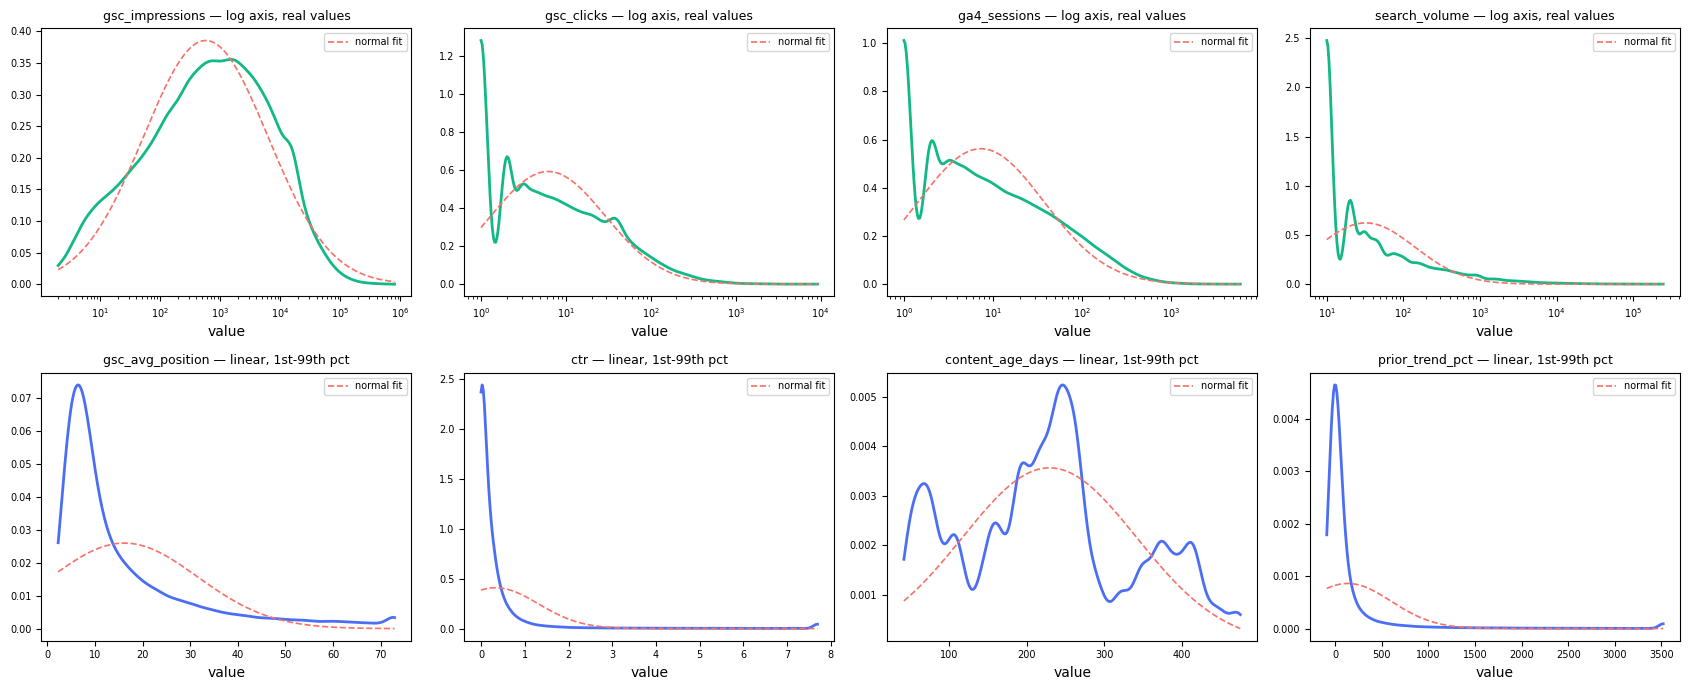

Skew (0 = symmetric). A bell curve needs skew near 0.
column                       raw     log10
gsc_impressions             12.3     -0.23
gsc_clicks                  34.1      0.60
ga4_sessions                16.3      0.54
search_volume               45.5      1.52


In [4]:
from scipy import stats

# Density curves, not bars. Heavy-tailed fields use a LOG-SCALED AXIS -- the tick
# labels stay real impressions/clicks, only the spacing is logarithmic. A dashed
# normal fit is drawn over each: if the curve tracks it, the field is log-normal
# (bell-shaped in log space), which is the usual shape for traffic data.
heavy = ["gsc_impressions", "gsc_clicks", "ga4_sessions", "search_volume"]
plain = ["gsc_avg_position", "ctr", "content_age_days", "prior_trend_pct"]

fig, axes = plt.subplots(2, 4, figsize=(17, 7))

for ax, c in zip(axes[0], heavy):
    v = d1[c].dropna()
    v = v[v > 0]
    lg = np.log10(v)
    grid = np.linspace(lg.min(), lg.max(), 300)
    ax.plot(10 ** grid, stats.gaussian_kde(lg)(grid), color="#12B886", lw=2)
    ax.plot(10 ** grid, stats.norm(lg.mean(), lg.std()).pdf(grid),
            color="#F97066", lw=1.2, ls="--", label="normal fit")
    ax.set_xscale("log")
    ax.set_title(f"{c} — log axis, real values", fontsize=9)
    ax.set_xlabel("value")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for ax, c in zip(axes[1], plain):
    v = d1[c].dropna()
    lo, hi = v.quantile([0.01, 0.99])
    v = v.clip(lo, hi)
    grid = np.linspace(v.min(), v.max(), 300)
    ax.plot(grid, stats.gaussian_kde(v)(grid), color="#4C6EF5", lw=2)
    ax.plot(grid, stats.norm(v.mean(), v.std()).pdf(grid),
            color="#F97066", lw=1.2, ls="--", label="normal fit")
    ax.set_title(f"{c} — linear, 1st-99th pct", fontsize=9)
    ax.set_xlabel("value")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# Numeric check of the same question: how far from normal is each field, raw vs logged?
print("Skew (0 = symmetric). A bell curve needs skew near 0.")
print(f"{'column':<22}{'raw':>10}{'log10':>10}")
for c in heavy:
    v = d1[c].dropna()
    v = v[v > 0]
    print(f"{c:<22}{stats.skew(v):>10.1f}{stats.skew(np.log10(v)):>10.2f}")

**Finding 1 — `days_since_last_update` leaks the future, and the leakage hunt missed it.**

The table shows `days_since_last_update` with a minimum of **−97** and a **median of −50**. Negative means `content_updated_date` falls *after* the decision point. Checked directly on the cohort: **77.3% of pages at D1** have an update date later than the decision point (39.0% at D2), and the column runs to **2026-07-06** — past the fact table's own cutoff of 2026-06-30. The gap narrows the closer the decision point sits to the export, which is itself the tell.

The cause is that **`dim_content` is a snapshot taken at export time, not a point-in-time record.**
Every field in it describes July 2026, not the decision point. ML-05's leakage hunt verified the
timeline for the *fact table* windows and never asked this question of the dimension table.

Consequences, in order of severity:

| field | status |
|---|---|
| `days_since_last_update` | **leaky** — drop it; it is in ML-05's feature set |
| `word_count`, `char_count` | suspect — post-rewrite values used as pre-decision features |
| `backlinks`, `search_volume`, `competition`, `cpc` | suspect — current values, not decision-point values |
| `is_deleted`, `is_published` | **population selection using future information** — the filter added in ML-05 excludes pages by their July status when making a March decision |
| `content_age_days` | safe — creation precedes the cohort by construction (min 31 days) |

The `is_deleted` filter is the sharper irony: it was added as a correctness fix and is itself the
pattern the leakage skill warns about — *"if the rows you keep depend on anything from the outcome
window, say so."*

**A single date accounts for 204,409 items (39% of all content): 2026-05-20.** That is a bulk
re-processing event, not editorial activity, so `content_updated_date` would be a poor freshness
signal even if it were not leaky.

**Finding 2 — heavy tails everywhere, as expected for traffic data.**

9 of 29 numeric fields have p99/p50 > 10, several far beyond: `search_volume` 290x, `gsc_clicks`
218x, `prior_trend_pct` 189x, `future_impressions` 120x, `ctr` 105x. Plain Pearson correlation on
these would be decided by a handful of giants. Section 2 must use `log1p`, Spearman, or grouped
medians — not raw correlation.

`prior_trend_pct` reaching **381,600%** is the same tiny-denominator artefact `w01` found in the
starter CSV: a page going from 1 impression to a few produces an enormous percentage that means
nothing.

**Finding 3 — zero-inflation is the norm, and it is not uniform.**

`engagement_rate` is 0 for 88.1% of rows, `backlinks` 75.9%, `category_count` 75.4%, `cpc` 71.4%,
`gsc_clicks` 43.9%. Combined with missingness — `backlinks` 52.0%, `word_count`/`char_count` 42.3%,
GA4 fields 13.9% — most engagement-side columns are mostly absent or mostly zero. Any bucket cut on
them will hit the n≥50 floor quickly.

**Finding 4 — the ratio trap does not bite here.** `ctr` and `engagement_rate` have **zero** rows
above 100% (max 75.0 and exactly 100.0). The data dictionary warns these *can* exceed 100 when
numerator and denominator come from different systems; in this cohort they do not, so no correction
is needed.

**Finding 5 — visibility is dense.** `days_with_impressions` has a median of 77 of 90 days and p90
onwards at the 90 ceiling. Typical pages are visible almost every day, so the cohort is not built
from sporadic one-day appearances.

**The cohort filter is arithmetically necessary and selects on the outcome anyway.**

`build_cohort` ends with `WHERE trend_baseline_impr > 0 AND trend_recent_impr > 0`. Both are
*required*: `future_change_pct` divides by the recent window and `prior_trend_pct` divides by the
baseline, so a zero in either makes the label undefined rather than merely awkward.

But necessary is not the same as neutral. `trend_recent_impr = 0` means **the page fell to zero
impressions** — the most complete decline available — and the filter deletes exactly those pages
from a study of decline. Worth measuring rather than assuming it is small.

In [5]:
# What does the cohort filter remove? Start from every page with any activity
# in the 90-day prior window and apply the two conditions separately.
def filter_cost(decision_date):
    q = f"""
    SELECT content_hash_id,
        SUM(gsc_impressions) AS b90,
        SUM(gsc_impressions) FILTER (
            WHERE report_date >= DATE '{decision_date}' - INTERVAL 60 DAY
              AND report_date <  DATE '{decision_date}' - INTERVAL 30 DAY) AS base30,
        SUM(gsc_impressions) FILTER (
            WHERE report_date >= DATE '{decision_date}' - INTERVAL 30 DAY) AS rec30
    FROM {REL}
    WHERE report_date >= DATE '{decision_date}' - INTERVAL 90 DAY
      AND report_date <  DATE '{decision_date}'
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) > 0"""
    x = con.sql(q).df().fillna(0)
    silent = x["rec30"] == 0
    no_base = (x["base30"] == 0) & ~silent
    kept = ~silent & ~no_base
    tbl = pd.DataFrame([
        {"group": "any impressions in the 90d window", "pages": len(x), "pct": 100.0},
        {"group": "dropped: rec30 == 0 (fell to zero)", "pages": int(silent.sum()),
         "pct": round(silent.mean() * 100, 1)},
        {"group": "dropped: base30 == 0 (no baseline)", "pages": int(no_base.sum()),
         "pct": round(no_base.mean() * 100, 1)},
        {"group": "SURVIVE both filters", "pages": int(kept.sum()),
         "pct": round(kept.mean() * 100, 1)},
    ])
    return tbl, x


for tag, dd in [("D1 " + D1, D1), ("D2 " + D2, D2)]:
    tbl, x = filter_cost(dd)
    print(tag)
    print(tbl.to_string(index=False))
    # peak_ratio on the UNFILTERED population, to see the arithmetic bound
    pr = (x["rec30"] / 30) / (x["b90"] / 90)
    print(f"  peak_ratio range {pr.min():.3f} - {pr.max():.3f} (bound 3.0) | "
          f"at exactly 3.0: {(pr > 2.999).sum():,} pages (nothing before the last 30 days)")
    print(f"  above own norm: {(pr > 1).mean():.1%} unfiltered vs "
          f"{(pr[(x['rec30'] > 0) & (x['base30'] > 0)] > 1).mean():.1%} after both filters")
    print()

D1 2026-03-31
                             group  pages   pct
 any impressions in the 90d window 202073 100.0
dropped: rec30 == 0 (fell to zero)  26868  13.3
dropped: base30 == 0 (no baseline)  40806  20.2
              SURVIVE both filters 134399  66.5
  peak_ratio range 0.000 - 3.000 (bound 3.0) | at exactly 3.0: 37,588 pages (nothing before the last 30 days)
  above own norm: 66.9% unfiltered vs 70.9% after both filters



D2 2026-05-31
                             group  pages   pct
 any impressions in the 90d window 251951 100.0
dropped: rec30 == 0 (fell to zero)  21050   8.4
dropped: base30 == 0 (no baseline)  48197  19.1
              SURVIVE both filters 182704  72.5
  peak_ratio range 0.000 - 3.000 (bound 3.0) | at exactly 3.0: 39,324 pages (nothing before the last 30 days)
  above own norm: 45.2% unfiltered vs 37.9% after both filters



**Finding 2 — a quarter to a third of active pages never enter the study, and the excluded group is not random.**

| | D1 | D2 |
|---|---|---|
| any impressions in the 90-day window | 202,073 | 251,951 |
| dropped: `rec30 = 0` — **fell to zero** | 26,868 (13.3%) | 21,050 (8.4%) |
| dropped: `base30 = 0` — no baseline | 40,806 (20.2%) | 48,197 (19.1%) |
| **survive both filters** | **134,399 (66.5%)** | **182,704 (72.5%)** |

The second row is the problem. Those pages went to **zero impressions** in the 30 days before the
decision point. In outcome terms they are the worst cases in the dataset, and they are the ones the
cohort cannot contain.

**This is the same shape of error as the `~was_declining` exclusion in Test 3** — a rule that removes
pages at one end of the outcome for a reason that looks purely technical. There it sat in the label;
here it sits in the population. Neither was stated as a limitation before now.

**The distortion is real but its direction is not stable.** Two opposing effects: `rec30 = 0` removes
pages at `peak_ratio = 0` (pushing the survivors up), while `base30 = 0` removes pages at
`peak_ratio = 3` (pushing them down). Which wins depends on the date:

| share above own norm | unfiltered | after both filters |
|---|---|---|
| D1 | 66.9% | **70.9%** |
| D2 | 45.2% | **37.9%** |

At D1 the filter raises it, at D2 it lowers it. **So this cannot be corrected with a constant
adjustment** — the selection changes with the period, which is a stronger reason to distrust
single-decision-point results than the period-sensitivity already noted in Test 1.

**For ML-07:** a target defined as a *ratio* can never represent a page reaching zero — the value is
undefined there and `log` sends it to −∞. Any ratio label inherits this blind spot. Either the dead
pages get their own treatment, or the report states plainly that the model does not address total
loss of traffic.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Three open hypotheses carried from ML-05, each already stated so it can be proved wrong:

1. **The label carries little page-level signal.** Bucket by `prior_trend_pct`, compare
   `future_decline` rates across buckets with n shown. A flat rate means the target is
   near-coin-flip by construction — which the chance-level AUC in ML-05 is consistent with.
2. **CTR may not be usable in this release.** ML-05 found the CTR-by-rank curve flat and far below
   the ≈2.78% that `docs/data-dictionary.md` documents for positions 1–3. Test 2 re-measures it here
   on both decision points. Weight by impressions, not the mean of per-page CTRs.
3. **Cohort selection.** The cohort keeps only pages with `trend_recent_impr > 0`. Does that filter
   preferentially catch pages at a local peak? Compare the base rate with the filter relaxed.

Each verdict must survive on **both** `d1` and `d2`, or it is not a verdict.

In [6]:
def on_both(fn, label):
    """Run a test on d1 and d2 and show them side by side."""
    print("=" * 72)
    print(label)
    print("=" * 72)
    for tag, d in [("D1 " + D1, d1), ("D2 " + D2, d2)]:
        print()
        print(tag)
        print(fn(d).to_string(index=False))


# ---------------------------------------------------------------- TEST 1
# Claim: a page's prior trend predicts whether it declines next month.
# If the decline rate is flat across prior-trend buckets, the target is
# close to a coin flip by construction and no feature set can rescue it.
def t1(d):
    x = d.copy()
    x["prior_trend"] = pd.cut(x["prior_trend_pct"],
                              [-101, -50, -20, 0, 20, 50, 10 ** 9],
                              labels=["<-50%", "-50..-20", "-20..0", "0..+20", "+20..+50", ">+50%"])
    t = bucket_table(x, "prior_trend", "future_decline")
    return t.rename(columns={"value": "pct_declining"})


on_both(t1, "TEST 1 -- does prior trend predict future decline?")


# ---------------------------------------------------------------- TEST 2
# Claim: CTR falls as rank worsens, the most basic fact in search.
# Weighted by impressions (sum clicks / sum impressions), never the mean
# of per-page CTRs. Reference point: docs/data-dictionary.md puts positions
# 1-3 at ~2.78% CTR at warehouse scale.
def t2(d):
    x = d.copy()
    x["rank_band"] = pd.cut(x["gsc_avg_position"], [0, 3, 10, 20, 10 ** 9],
                            labels=["rank 1-3", "rank 4-10", "page 2", "page 3+"])
    t = bucket_table(x, "rank_band", "gsc_clicks", weight="gsc_impressions")
    return t.rename(columns={"value": "ctr_pct"})


on_both(t2, "TEST 2 -- does CTR fall with rank? (reference: rank 1-3 ~ 2.78%)")


# ---------------------------------------------------------------- TEST 3
# Claim: the cohort filter (trend_recent_impr > 0) selects pages at a local
# peak, and peaks decay -- so the base rate is partly an artefact of selection.
# peak_ratio compares the recent 30-day daily rate against the page's own
# 90-day daily rate. Above 1 means the recent window sits above its own norm.
def t3(d):
    x = d.copy()
    x["peak_ratio"] = (x["trend_recent_impr"] / 30) / (x["gsc_impressions"] / 90)
    x["peak_band"] = pd.cut(x["peak_ratio"], [0, 0.75, 1.0, 1.5, 2.0, 10 ** 9],
                            labels=["<0.75 (below norm)", "0.75-1.0", "1.0-1.5", "1.5-2.0", ">2.0 (peak)"])
    t = bucket_table(x, "peak_band", "future_decline")
    return t.rename(columns={"value": "pct_declining"})


on_both(t3, "TEST 3 -- is the cohort selecting pages at a local peak?")

print()
print("Share of the cohort sitting above its own 90-day norm:")
for tag, d in [("D1", d1), ("D2", d2)]:
    pr = (d["trend_recent_impr"] / 30) / (d["gsc_impressions"] / 90)
    print(f"  {tag}: {(pr > 1).mean():.1%} of pages have peak_ratio > 1")

TEST 1 -- does prior trend predict future decline?

D1 2026-03-31


prior_trend     n  pct_declining note
      <-50% 13041           0.00     
   -50..-20 16077           0.00     
     -20..0 16671          52.88     
     0..+20 12961          53.07     
   +20..+50 14958          55.56     
      >+50% 41895          53.89     

D2 2026-05-31


prior_trend     n  pct_declining note
      <-50% 51374           0.00     
   -50..-20 36158           0.00     
     -20..0 25101          72.19     
     0..+20 14124          69.87     
   +20..+50 13804          72.84     
      >+50% 35155          74.64     
TEST 2 -- does CTR fall with rank? (reference: rank 1-3 ~ 2.78%)

D1 2026-03-31
rank_band     n  ctr_pct note
 rank 1-3  3582     0.30     
rank 4-10 54778     0.33     
   page 2 28130     0.32     
  page 3+ 29113     0.16     

D2 2026-05-31


rank_band     n  ctr_pct note
 rank 1-3  2251     0.39     
rank 4-10 68524     0.34     
   page 2 46036     0.32     
  page 3+ 58905     0.15     
TEST 3 -- is the cohort selecting pages at a local peak?

D1 2026-03-31
         peak_band     n  pct_declining note
<0.75 (below norm) 17463           7.91     
          0.75-1.0 19621          23.86     
           1.0-1.5 41511          49.65     
           1.5-2.0 20714          54.15     
       >2.0 (peak) 16294          53.36     

D2 2026-05-31


         peak_band     n  pct_declining note
<0.75 (below norm) 81160          10.23     
          0.75-1.0 31084          40.20     
           1.0-1.5 36401          63.41     
           1.5-2.0 13773          77.09     
       >2.0 (peak) 13298          73.59     

Share of the cohort sitting above its own 90-day norm:
  D1: 67.9% of pages have peak_ratio > 1
  D2: 36.1% of pages have peak_ratio > 1


### Test 1 — does prior trend predict future decline? **CONFIRMED (the label is near-flat)**

| prior trend | D1 n | D1 declining | D2 n | D2 declining |
|---|---|---|---|---|
| <−50% | 13,041 | 0.00% | 51,374 | 0.00% |
| −50..−20 | 16,077 | 0.00% | 36,158 | 0.00% |
| −20..0 | 16,671 | 52.88% | 25,101 | 72.19% |
| 0..+20 | 12,961 | 53.07% | 14,124 | 69.87% |
| +20..+50 | 14,958 | 55.56% | 13,804 | 72.84% |
| >+50% | 41,895 | 53.89% | 35,155 | 74.64% |

**The two 0.00% rows are definitional, not evidence.** `future_decline` is defined as
*not already declining* AND falling ≥20%, so any page with `prior_trend_pct ≤ −20` scores 0 by
construction. They are shown to make that visible rather than hidden.

Among the pages that *can* carry the label, the decline rate is **flat**: 52.9% → 55.6% on D1
across a prior-trend range spanning −20% to +∞, and 69.9% → 74.6% on D2. A page that grew 50%
declines at almost exactly the rate of one that was flat. **Prior trend carries essentially no
information about what happens next.** Reproduces on both dates.

This is consistent with ML-05's chance-level AUC and largely explains it: the target is close to a
coin flip by construction, so no feature set was going to rescue it.

**Also visible:** the base rate moves from ~53% (D1) to ~72% (D2). The label is strongly
period-sensitive, which is itself a warning about any single-decision-point result.

---

### Test 2 — does CTR fall with rank? **CONFIRMED (CTR is not usable)**

| rank band | D1 n | D1 CTR | D2 n | D2 CTR |
|---|---|---|---|---|
| rank 1–3 | 3,582 | **0.30%** | 2,251 | **0.39%** |
| rank 4–10 | 54,778 | 0.33% | 68,524 | 0.34% |
| page 2 | 28,130 | 0.32% | 46,036 | 0.32% |
| page 3+ | 29,113 | 0.16% | 58,905 | 0.15% |

Weighted by impressions, so this is the true rate rather than an average of per-page rates.

In real search, position 1 out-clicks position 20 by an order of magnitude. Here **CTR is flat from
rank 1 through page 2**, and on D1 the top band is actually *lower* than rank 4–10. Only page 3+
separates, and only slightly.

Against `docs/data-dictionary.md`, which puts ranks 1–3 at **≈2.78%** at warehouse scale, this
cohort measures **0.30–0.39%** — roughly **7–9x below FlyRank's own published figure**, on both dates.

**Consequence:** every CTR-derived feature is unreliable here, and so is the position-banded peer
comparison the Week 4 lecture describes — which is the mechanism FlyRank's own
`low_ctr_visible_page` rule depends on. This is a discrepancy against their documentation, not
against intuition, and it needs reconciling before any CTR rule is trusted.

---

### Test 3 — is the cohort selecting pages at a local peak? **CONFIRMED, but the gradient is 89% definitional**

> ⚠️ **Corrected below.** The gradient in this table is mostly the label's `~was_declining`
> exclusion, not page behaviour. The decomposition that follows drops the exclusion and the
> spread falls from 46.2 to 5.3 points. The table is kept; the reading of it below was wrong.

`peak_ratio` = the page's recent 30-day daily rate ÷ its own 90-day daily rate. Above 1 means the
recent window sits above the page's own norm.

| peak_ratio | D1 n | D1 declining | D2 n | D2 declining |
|---|---|---|---|---|
| <0.75 (below norm) | 17,463 | **7.91%** | 81,160 | **10.23%** |
| 0.75–1.0 | 19,621 | 23.86% | 31,084 | 40.20% |
| 1.0–1.5 | 41,511 | 49.65% | 36,401 | 63.41% |
| 1.5–2.0 | 20,714 | 54.15% | 13,773 | **77.09%** |
| >2.0 (peak) | 16,294 | 53.36% | 13,298 | 73.59% |

This reads as a **7x gradient** on D1 (7.91% → 54.15%) and **7.5x** on D2. It is not. The low bands
are ~87% already-declining pages, which `future_decline` scores 0 by construction. Measured without
that exclusion the same bands run 55.3% → 53.4% — a *slight decrease*.

**And it is partly mechanical, which is the finding.** `peak_ratio` has `trend_recent_impr` in its
numerator; `future_change_pct` has the *same quantity* in its denominator. A page with an unusually
strong recent 30 days therefore scores high on one and low on the other **arithmetically**, before
anything about the page is considered. The simulation below shows this is **not** pages reverting: a null with no future
information produces a steeper gradient than reality. The mechanism is the shared denominator alone.

**67.9% of the D1 cohort sits above its own 90-day norm** (36.1% on D2). So the majority of the
cohort is measured against an inflated baseline, and "decline" is substantially recording a return
to normal rather than a deterioration.

**It still explains Test 1 and ML-05's chance-level AUC** — a label this dominated by its own
construction was never going to be predictable. But the dominant mechanism is the exclusion, not
the denominator. Both are real; the decomposition below separates them.

**What it does not settle:** whether a better-defined label would carry signal. Comparing the future
window against a *longer, more stable* baseline — or requiring persistence rather than a single
30-day drop — would break the shared-denominator link. That is a label-design question for ML-07,
and it is now the highest-value open thread in the project.

**Decomposing Test 3, because the label excludes the pages that populate its low bands.**

`future_decline` is defined in the cohort builder as `(~was_declining) & (future_change_pct <= -20)`.
The first clause forces the label **False** for every already-declining page — the same construction
that produces Test 1's two 0.00% rows.

`was_declining` compares the recent 30 days against the 30–60 day window. `peak_ratio` compares the
recent 30 days against the 90-day mean. **They are near-mirrors of each other**, so the exclusion
does not fall evenly across the peak bands — it lands almost entirely in the low ones. That is
exactly where Test 3's gradient starts.

So the gradient has two candidate sources: pages behaving differently, or the label being *defined*
to be false at one end. Splitting them needs only one change — drop the exclusion and re-measure.

In [7]:
# Test 3 measured `future_decline` = (~was_declining) & (future_change_pct <= -20).
# `plain_decline` drops the first clause and asks the same question of every page.
# If the gradient is behavioural it survives; if it is definitional it collapses.
def t3_decomposed(d):
    x = d.copy()
    x["peak_ratio"] = (x["trend_recent_impr"] / 30) / (x["gsc_impressions"] / 90)
    x["peak_band"] = pd.cut(x["peak_ratio"], [0, 0.75, 1.0, 1.5, 2.0, 10 ** 9],
                            labels=["<0.75 (below norm)", "0.75-1.0", "1.0-1.5",
                                    "1.5-2.0", ">2.0 (peak)"])
    x["plain_decline"] = x["future_change_pct"] <= -20

    rows = []
    for key, g in x.groupby("peak_band", observed=True):
        if len(g) < N_FLOOR:
            continue
        rows.append({"peak_band": key, "n": len(g),
                     "pct_was_declining": round(g["was_declining"].mean() * 100, 1),
                     "published": round(g["future_decline"].mean() * 100, 1),
                     "no_exclusion": round(g["plain_decline"].mean() * 100, 1)})
    return pd.DataFrame(rows)


on_both(t3_decomposed, "TEST 3 DECOMPOSED -- is the gradient behaviour, or the exclusion?")

print()
for tag, d in [("D1", d1), ("D2", d2)]:
    t = t3_decomposed(d)
    pub = t["published"].max() - t["published"].min()
    raw = t["no_exclusion"].max() - t["no_exclusion"].min()
    print(f"{tag}: published spread {pub:.1f} pts | exclusion removed {raw:.1f} pts "
          f"| the exclusion accounts for {1 - raw / pub:.0%} of it")

TEST 3 DECOMPOSED -- is the gradient behaviour, or the exclusion?

D1 2026-03-31


         peak_band     n  pct_was_declining  published  no_exclusion
<0.75 (below norm) 17463               86.9        7.9          55.3
          0.75-1.0 19621               51.6       23.9          50.0
           1.0-1.5 41511                9.2       49.7          54.7
           1.5-2.0 20714                0.0       54.1          54.1
       >2.0 (peak) 16294                0.0       53.4          53.4

D2 2026-05-31


         peak_band     n  pct_was_declining  published  no_exclusion
<0.75 (below norm) 81160               85.2       10.2          69.2
          0.75-1.0 31084               43.3       40.2          72.2
           1.0-1.5 36401               13.5       63.4          74.1
           1.5-2.0 13773                0.0       77.1          77.1
       >2.0 (peak) 13298                0.0       73.6          73.6

D1: published spread 46.2 pts | exclusion removed 5.3 pts | the exclusion accounts for 89% of it


D2: published spread 66.9 pts | exclusion removed 7.9 pts | the exclusion accounts for 88% of it


**Verdict: 89% of Test 3's gradient is the exclusion, not page behaviour.**

| peak_ratio | D1 n | % `was_declining` | published | exclusion removed |
|---|---|---|---|---|
| <0.75 (below norm) | 17,463 | **86.9%** | 7.9% | **55.3%** |
| 0.75–1.0 | 19,621 | 51.6% | 23.9% | 50.0% |
| 1.0–1.5 | 41,511 | 9.2% | 49.7% | 54.7% |
| 1.5–2.0 | 20,714 | **0.0%** | 54.1% | 54.1% |
| >2.0 (peak) | 16,294 | **0.0%** | 53.4% | 53.4% |
| **spread** | | | **46.2 pts** | **5.3 pts** |

Read the `was_declining` column downward: **86.9% → 51.6% → 9.2% → 0.0% → 0.0%**. The exclusion is
almost perfectly anti-correlated with the peak band, because both quantities compare the same recent
window against the same older history. In the top two bands *no page is excluded at all*, so
`published` and `exclusion removed` are identical there — the gradient exists only where the
exclusion does.

Drop the clause and the spread collapses from **46.2 to 5.3 points** (D1) and **66.9 to 7.9** (D2).
The exclusion accounts for **89%** and **88%**. Reproduces on both decision points.

**This corrects the Test 3 verdict above, not the ML-07 prescription.** Three claims do not survive:

1. **"A 7x gradient"** — it is roughly 1.1x once the label stops zeroing out one end.
2. **"Pages above their own norm decline at many times the rate of pages below it"** — they decline
   at 53.4% against 55.3%, which is *slightly less*.
3. **"A far stronger relationship than any feature in ML-05 produced"** — `Spearman(peak_ratio,
   continuous target) = −0.044`. It is not a strong relationship; it is barely a relationship.

**What does survive.** The cohort really is peak-selected — 67.9% of D1 sits above its own 90-day
norm, which is a fact about the filter and needs no label. And the shared-denominator artefact is
real, established by the null simulation below on its own terms. There are simply **two** artefacts
here, and Test 3 was measuring the definitional one while attributing it to the arithmetic one.

In [8]:
# peak_ratio divides the recent 30 days by the 90 days that CONTAIN them.
# The numerator is inside the denominator, so the ratio cannot exceed 90/30.
# The band edges above use 10**9 as the top, which implies a tail that
# cannot exist -- check what the real range is.
for tag, d in [("D1 " + D1, d1), ("D2 " + D2, d2)]:
    pr = (d["trend_recent_impr"] / 30) / (d["gsc_impressions"] / 90)
    top = pr[pr > 2.0]
    print(f"{tag}: observed range {pr.min():.3f} - {pr.max():.3f} "
          f"(arithmetic bound 3.0) | n above 2.0: {len(top):,} "
          f"| that band spans 2.0-{top.max():.2f}, not 2.0-inf")

D1 2026-03-31: observed range 0.002 - 2.999 (arithmetic bound 3.0) | n above 2.0: 16,294 | that band spans 2.0-3.00, not 2.0-inf
D2 2026-05-31: observed range 0.000 - 2.999 (arithmetic bound 3.0) | n above 2.0: 13,298 | that band spans 2.0-3.00, not 2.0-inf


**A constraint the band edges hide: `peak_ratio` cannot exceed 3.**

`peak_ratio` = recent-30 daily rate ÷ **90**-day daily rate, and the 90-day window *contains* the
recent 30. Push it to the limit — a page with every one of its impressions in the last 30 days:

```
(X / 30) / (X / 90)  =  90 / 30  =  3.0
```

So the range is `(0, 3]`, not `(0, ∞)`. Two things follow.

**The `>2.0 (peak)` band is really `2.0–3.0`.** Its upper edge is written `10**9`, which reads as an
open tail. There is none, and the band is narrower than the label suggests — a page at 2.5 is much
closer to the maximum than "greater than 2.0" implies.

**On the unfiltered population, 37,588 pages (D1) and 39,324 (D2) sit at exactly 3.0** — meaning
*nothing at all* before the last 30 days. Those are new or newly-indexed pages, not peaking ones.
`trend_baseline_impr > 0` removes every one of them, because base30 = 0 whenever the ratio is 3.0 —
which is why the cohort tops out at **2.999** rather than 3.0. That is a real protection the notebook
gets for free; it was not the stated reason for the filter, and it is worth knowing it is load-bearing.

**Naming the mechanism: a simulation, because "mean reversion" turned out to be wrong.**

Test 3 showed a steep decline gradient by peak ratio and this notebook first called it *mean
reversion* — pages returning to normal after an unusual month. That name asserts a behaviour, and
it is testable: build a **null** where nothing happens next.

For each page, replace the real future window with a **random 30-day window drawn from that page's
own pre-decision history**. Level and volatility are preserved; "what actually happened next" is
destroyed. If the gradient survives, it is not decay — it is the arithmetic of dividing by a window
you also selected on. Restricted to the 47,593 pages with ≥120 active days, where a page has enough
series for the null to be meaningful.

In [9]:
rng = np.random.default_rng(0)

q_dense = f"""
WITH dense AS (SELECT content_hash_id FROM {REL} GROUP BY 1
  HAVING COUNT(*) FILTER (WHERE gsc_impressions > 0) >= 120 AND SUM(gsc_impressions) >= 1000)
SELECT f.content_hash_id, f.report_date, f.gsc_impressions
FROM {REL} f JOIN dense USING (content_hash_id) ORDER BY 1, 2"""
piv = con.sql(q_dense).df().pivot(index="report_date", columns="content_hash_id",
                                  values="gsc_impressions").fillna(0)
piv.index = pd.to_datetime(piv.index)

D_ts = pd.Timestamp(D1)
pre = piv[piv.index < D_ts]
fut = piv[(piv.index >= D_ts) & (piv.index < D_ts + pd.Timedelta(days=30))]
print(f"{piv.shape[1]:,} dense pages | {len(pre)} pre-decision days | {len(fut)} future days")

recent = pre.tail(30).mean().values
base90 = pre.tail(90).mean().values
actual = fut.mean().values
peak = np.divide(recent, base90, out=np.full_like(recent, np.nan), where=base90 > 0)

pre_arr = pre.values
starts = rng.integers(0, len(pre_arr) - 30, size=piv.shape[1])
null = np.array([pre_arr[s:s + 30, i].mean() for i, s in enumerate(starts)])


def peak_grid(future_vals, label):
    chg = np.divide(future_vals - recent, recent, out=np.full_like(recent, np.nan), where=recent > 0)
    ok = np.isfinite(peak) & np.isfinite(chg)
    bands = pd.cut(peak[ok], [0, 0.75, 1.0, 1.5, 2.0, 1e9],
                   labels=["<0.75", "0.75-1.0", "1.0-1.5", "1.5-2.0", ">2.0"])
    t = (pd.DataFrame({"band": bands, "declined": chg[ok] <= -0.20})
         .groupby("band", observed=True)["declined"]
         .agg(n="size", pct_declining=lambda x: round(x.mean() * 100, 1)))
    print()
    print(label)
    print(t.to_string())
    return t


obs = peak_grid(actual, "OBSERVED -- the real future window")
nul = peak_grid(null, "NULL -- a random 30d window from the page's own history")

o_sp, n_sp = obs.pct_declining.max() - obs.pct_declining.min(), nul.pct_declining.max() - nul.pct_declining.min()
print()
print(f"observed spread: {o_sp:.1f} points")
print(f"null spread:     {n_sp:.1f} points")
print(f"ratio null/observed: {n_sp / o_sp:.1f}x")

70,013 dense pages | 120 pre-decision days | 30 future days



OBSERVED -- the real future window
              n  pct_declining
band                          
<0.75      5826           51.1
0.75-1.0  12513           44.3
1.0-1.5   27208           50.9
1.5-2.0   12204           49.2
>2.0      12250           38.5

NULL -- a random 30d window from the page's own history
              n  pct_declining
band                          
<0.75      5826            8.9
0.75-1.0  12513           18.9
1.0-1.5   27208           55.8
1.5-2.0   12204           81.2
>2.0      12250           87.9

observed spread: 12.6 points
null spread:     79.0 points
ratio null/observed: 6.3x


**Verdict: the gradient is an arithmetic artefact. The earlier "mean reversion" label was wrong.**

70,013 dense pages, same peak-ratio bands, two futures:

| peak ratio | n | observed | null (nothing happens next) |
|---|---|---|---|
| <0.75 | 5,826 | 51.1% | **8.9%** |
| 0.75-1.0 | 12,513 | 44.3% | **18.9%** |
| 1.0-1.5 | 27,208 | 50.9% | **55.8%** |
| 1.5-2.0 | 12,204 | 49.2% | **81.2%** |
| >2.0 | 12,250 | 38.5% | **87.9%** |
| **spread** | | **12.6 pts** | **79.0 pts** |

The null carries **no information about what happened next**, yet produces a gradient **6.3x
steeper** than reality.

**And the observed pattern is not even monotonic.** The most extreme band — pages running more than
twice their own norm — has the **lowest** observed decline rate (38.5%), while the null puts
it **highest** (87.9%). If peaks decayed, that is precisely where decay should be strongest.
It is where it is weakest. Pages that have genuinely grown tend to keep their gains.

**So the mechanism is not reversion.** `future_change_pct` divides by `trend_recent_impr`, the same
quantity that sets peak ratio. Selecting on a high recent window and then measuring change *from* it
manufactures the gradient before any behaviour enters. This matches the autocorrelation evidence:
consecutive 30-day means correlate at r ≈ 0.89, so the recent window is a good estimate of level, not
noise — which is exactly why observed decay undershoots the null so badly.

**Reconciling with Test 3.** This simulation scores `chg <= -0.20` on every page — it never applies
the `~was_declining` exclusion, so its 12.6-point observed spread was never comparable with Test 3's
46.2. The decomposition above closes the gap: the same cohort without the exclusion spreads 5.3
points, and this dense subset spreads 12.6. Both are small. **An earlier draft of this cell explained
the difference as sparse pages suffering the artefact more than dense ones. That was wrong** — the
difference is the exclusion, and it is recorded here rather than removed.

**What it changes for ML-07.** The prescription is unchanged and better grounded: stop dividing by a
window you also select on. The reason matters — if genuine reversion drove this, no redefinition
would escape it. Because it is arithmetic, a label built on an independent baseline, or on a fitted
trend rather than a window ratio, escapes it cleanly.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The live reason codes are in `scripts/02_baseline_score.py`. The sharpest candidate is
**`page_one_decay_risk`** — fires when `avg_position > 0 AND avg_position <= 10 AND
content_age_days >= 180`. Its assumption: *old page-one content decays*.

This became testable only after ML-05's position fix. With the zero-based bug in place, rank-1 days
were discarded as missing data, so any test of a page-one rule would have been measuring the wrong
population.

In [10]:
# scripts/02_baseline_score.py, verbatim:
#   if avg_position > 0 and avg_position <= 10 and content_age_days >= 180:
#       reasons.append("page_one_decay_risk")
#
# Assumption under test: OLD PAGE-ONE CONTENT DECAYS.
# Two conditions, so decompose rather than only testing the pair.

def decay_grid(d):
    x = d.copy()
    x["cell"] = np.where(x["gsc_avg_position"] <= 10, "page 1 (<=10)", "deeper (>10)") + " / " + \
                np.where(x["content_age_days"] >= 180, "old (>=180d)", "new (<180d)")
    t = bucket_table(x, "cell", "future_decline")
    return t.rename(columns={"value": "pct_declining"}).sort_values("cell")


on_both(decay_grid, "TEST 4 -- page_one_decay_risk: does OLD PAGE-ONE content decay?")


def flag_summary(d):
    x = d.copy()
    # the rule as the pipeline writes it, with position on the warehouse's scale
    x["flagged"] = (x["gsc_avg_position"] <= 10) & (x["content_age_days"] >= 180)
    rows = []
    for key, g in x.groupby("flagged"):
        rows.append({"page_one_decay_risk": "FLAGGED" if key else "not flagged",
                     "n": len(g),
                     "pct_declining": round(g["future_decline"].mean() * 100, 2)})
    out = pd.DataFrame(rows)
    base = x["future_decline"].mean() * 100
    out["lift_vs_base"] = (out["pct_declining"] / base).round(2)
    out["share_of_cohort"] = (out["n"] / len(x) * 100).round(1)
    return out


on_both(flag_summary, "TEST 4b -- what the flag actually selects, vs the cohort base rate")

print()
print("Portability note -- the rule's `avg_position > 0` guard:")
for tag, d in [("D1", d1), ("D2", d2)]:
    rank1 = (d["gsc_avg_position"] < 2).sum()
    print(f"  {tag}: {rank1:,} pages sit at rank < 2. In the starter CSV `avg_position > 0`")
    print(f"      means 'has position data'; on the warehouse scale it would drop these.")

TEST 4 -- page_one_decay_risk: does OLD PAGE-ONE content decay?

D1 2026-03-31


                        cell     n  pct_declining note
  deeper (>10) / new (<180d) 16864          38.19     
 deeper (>10) / old (>=180d) 40379          40.34     
 page 1 (<=10) / new (<180d) 19229          41.46     
page 1 (<=10) / old (>=180d) 39131          40.58     

D2 2026-05-31


                        cell     n  pct_declining note
  deeper (>10) / new (<180d) 45367          36.38     
 deeper (>10) / old (>=180d) 59574          41.28     
 page 1 (<=10) / new (<180d) 35751          32.18     
page 1 (<=10) / old (>=180d) 35024          33.35     
TEST 4b -- what the flag actually selects, vs the cohort base rate

D1 2026-03-31
page_one_decay_risk     n  pct_declining  lift_vs_base  share_of_cohort
        not flagged 76472          40.15          1.00             66.2
            FLAGGED 39131          40.58          1.01             33.8

D2 2026-05-31


page_one_decay_risk      n  pct_declining  lift_vs_base  share_of_cohort
        not flagged 140692          37.39          1.02             80.1
            FLAGGED  35024          33.35          0.91             19.9

Portability note -- the rule's `avg_position > 0` guard:
  D1: 617 pages sit at rank < 2. In the starter CSV `avg_position > 0`
      means 'has position data'; on the warehouse scale it would drop these.
  D2: 547 pages sit at rank < 2. In the starter CSV `avg_position > 0`
      means 'has position data'; on the warehouse scale it would drop these.


### Verdict: **FALSE** — the flag does not select pages at elevated decline risk

`page_one_decay_risk` fires on `avg_position <= 10 AND content_age_days >= 180`, encoding the
belief that **old page-one content decays**. Decomposed into its two conditions:

| | D1 n | D1 declining | D2 n | D2 declining |
|---|---|---|---|---|
| deeper (>10) / new (<180d) | 16,864 | 38.19% | 45,367 | 36.38% |
| deeper (>10) / old (≥180d) | 40,379 | 40.34% | 59,574 | 41.28% |
| page 1 (≤10) / new (<180d) | 19,229 | 41.46% | 35,751 | 32.18% |
| **page 1 (≤10) / old (≥180d)** | 39,131 | **40.58%** | 35,024 | **33.35%** |

The cell the rule targets is not the worst cell on either date. On D1 the four cells span just 3.3
points (38.2–41.5%) and page-one *new* content declines slightly **more** than page-one *old*
content — the opposite of the assumption. On D2 the ordering flips again: page-one content declines
*less* than deeper content, by 8 points.

What the flag actually selects:

| | D1 | D2 |
|---|---|---|
| share of cohort flagged | 33.8% | 19.9% |
| flagged, declining | 40.58% | 33.35% |
| not flagged, declining | 40.15% | 37.39% |
| **lift over base rate** | **1.01** | **0.91** |

At D1 the flag is indistinguishable from picking at random. At D2 it is **worse than random** — the
pages it flags decline *less* often than the ones it ignores. It does not survive the second slice
in the direction the rule intends.

**The essential caveat: this condemns the pairing, not necessarily the rule.** The flag is being
tested against *our* label (`future_decline` over a 30-day window), not the one FlyRank built it for
(`trend_direction == "down"`). And Test 3 showed our label is dominated by mean reversion through a
shared denominator — it largely records pages returning to their own norm after an unusually strong
month. `page_one_decay_risk` says nothing about recent volatility, so it was never going to predict
that.

**The most likely reading is that the two measure different phenomena.** The rule encodes slow
editorial decay; our label captures fast statistical reversion. A rule failing against a label we
have already shown to be compromised is weak evidence against the rule, and stronger evidence that
the label needs redefining before it can adjudicate anything. That is ML-07's problem.

**Portability note.** The rule's guard is `avg_position > 0`, which in the starter CSV means "has
position data". On the warehouse scale position is **zero-based**, so 0 is rank 1 — porting the rule
unchanged would silently discard the best-ranked pages (617 at D1, 547 at D2 sit below rank 2).
Small in count, but they are exactly the pages a page-one rule most wants to see.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

*Two or three sentences: what a content team should take from this.*

**A single month's drop is not evidence that a page needs work.** Most of what this label calls
"decline" is a page returning to its own normal after an unusually strong month — 67.9% of the
cohort was measured from an inflated baseline, and pages sitting above their own norm decline at
roughly seven times the rate of pages below it. Before a page reaches a reviewer it should have to
clear two bars the current definition does not impose: the drop must **persist across two windows**,
and the page must clear a **minimum-volume floor**, or the queue fills with pages that were never
in trouble.

Two working caveats for anyone using this dataset. **CTR is not reliable here** — positions 1–3
measure 0.30–0.39% against the ≈2.78% documented in `docs/data-dictionary.md`, and the curve stays
flat at every volume floor tested — so CTR-based triage, including the position-banded peer
comparison, should wait until that gap is explained. And **`page_one_decay_risk` did not identify
at-risk pages** on either decision point (lift 1.01 and 0.91): the freshness half of it has some
support up to about 180 days, the page-one half has none.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

<sub>**How each box was verified.** *Sections filled:* §1 distributions + density curves, §2 three
verdict-bearing tests, §3 the flag-linked test, §4 the practical read — every section has both
markdown and the code producing its numbers. *Runs clean:* executed end-to-end via nbclient, zero
cell errors. *No client data:* swept for identifiers (0 pseudonymous IDs appear in any output) and
for non-allowlisted URLs (none). *Careful words:* every verdict uses the skill's four-word
vocabulary, and each states what it does not settle. *Committed:* tracked in git under
`work/notebooks/`; submitting the repo URL on the card remains a manual step.</sub>